In [19]:
import scanpy as sc
import pandas as pd
import liana as li

In [20]:
adata = sc.read_h5ad("adata_xeno_with_symbols.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 75467 × 41560
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'


In [21]:
adata = sc.read_h5ad("adata_xeno_with_symbols.h5ad")
adata = adata[adata.obs["Phenograph"].notna()].copy()
adata = adata[:, adata.var["ORTHOLOG_HUMAN_SYMBOL"].notna()].copy()
adata.var_names = adata.var["ORTHOLOG_HUMAN_SYMBOL"].astype(str)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 33985 × 16028
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'


In [22]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

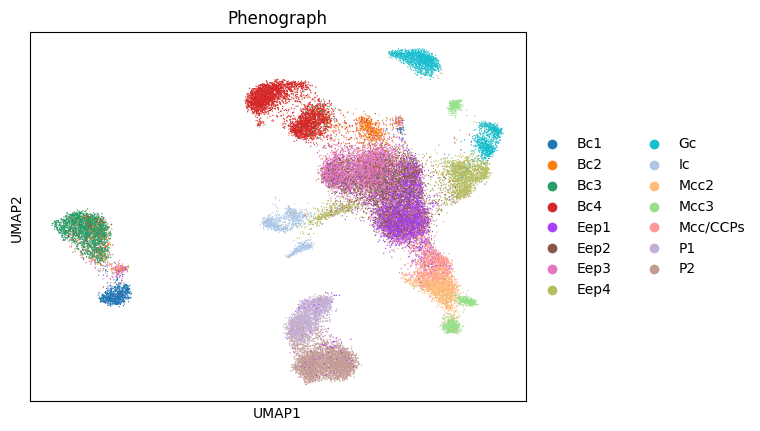

In [23]:
sc.pl.umap(adata, color="Phenograph")

In [24]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [25]:
adata_st22 = adata[adata.obs["Stages"] == "st22"].copy()

In [26]:
adata_st22.var_names

Index(['SUCLG1', 'ADRA1D', 'SMOX', 'RNF24', 'GNRH2', 'AVP', 'UBOX5', 'LZTS3',
       'ATRN', 'SLC4A11',
       ...
       'CLDN6-2', 'SRRM2-1', 'PHGDH-1', 'RRAGA-1', 'GBP7', 'GBP4', 'PPIL3',
       'NIF3L1', 'RNF112', 'MFAP4'],
      dtype='object', name='ORTHOLOG_HUMAN_SYMBOL', length=16028)

In [6]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [29]:
cellphonedb(
            adata_st22,
            groupby='CellType',
            resource_name='consensus',
            expr_prop=0.1,
            verbose=True,
            key_added='cpdb_res',
            use_raw=False
        )

Using resource `consensus`.
Using `.X`!
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2099 features of mat are empty, they will be removed.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\_pipe_utils\_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\_pipe_utils\_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.62 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5217 samples and 560 features


100%|██████████| 1000/1000 [00:04<00:00, 207.60it/s]


In [40]:
li.mt.rank_aggregate(adata_st22, 
                     groupby='CellType',
                     resource_name='consensus',
                     expr_prop=0.01,
                     verbose=True,
                     use_raw=False)

Using resource `consensus`.
Using `.X`!
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2099 features of mat are empty, they will be removed.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\_pipe_utils\_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\_pipe_utils\_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.62 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5217 samples and 560 features
Assuming that counts were `natural` log-normalized!


c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\sc\_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Running CellPhoneDB


100%|██████████| 1000/1000 [00:04<00:00, 210.81it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [33]:
print(adata_st22.uns.keys())


odict_keys(['log1p', 'pca', 'neighbors', 'umap', 'Phenograph_colors', 'cpdb_res', 'liana_res'])


In [55]:
adata_st22.uns["liana_res"]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
227,Basal,Early epithelial progenitor,MDK,NCL,0.644004,0.000,0.158160,0.347303,0.248480,0.160680,0.961102,0.002750,0.000003
126,Basal,Basal,MDK,NCL,0.619229,0.000,0.151348,0.287955,0.325431,0.153760,0.960270,0.003608,0.000012
648,Early epithelial progenitor,Early epithelial progenitor,MDK,NCL,0.608106,0.000,0.075557,0.153026,0.127847,0.076761,0.944683,0.030077,0.000072
581,Early epithelial progenitor,Basal,MDK,NCL,0.583332,0.000,0.072303,0.093677,0.204798,0.073455,0.943521,0.079417,0.000104
1609,Multiciliated,Early epithelial progenitor,MDK,NCL,0.586696,0.000,0.026290,0.037152,0.084475,0.026709,0.909695,0.327579,0.000350
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,Basal,Ionocyte,SEMA4C,PLXNB2,0.006330,0.997,0.000039,-0.074601,-0.011888,0.028866,0.279500,1.000000,1.000000
408,Basal,Ionocyte,PSEN1,NCSTN,0.008031,0.163,0.000063,0.028601,0.002608,0.067243,0.329860,0.157497,1.000000
711,Early epithelial progenitor,Goblet,MFAP2,NOTCH1,0.007427,0.948,0.000043,-0.037931,-0.004163,0.059969,0.289729,1.000000,1.000000
204,Basal,Early epithelial progenitor,GNAS,ADCY9,0.009987,0.107,0.000068,0.073063,0.000047,0.055657,0.338764,0.309173,1.000000


In [54]:
res = adata_st22.uns["liana_res"]
print(res.columns)


Index(['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means',
       'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc',
       'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank'],
      dtype='object')


In [36]:
paper_xeno = [
    "has1.S", "eef1ao.L",
    "tubb4b.L", "dynll1.S", "tekt2.S", "cav3.S",
    "foxa1.L", "tp63.L", "pfn1.L", "ano1.L", "anxa2.S",
    "angpt4.S", "itln1.L", "atp12a.L", "otog.L", "otogl2.L", "mucXS",
    "foxi1.S", "atp6v1g3.S", "atp6v1b1.L", "ca2.L", "cystm1.S",
    "notch2.L", "hes1.L", "hes8.L", "smad3.L", "smad7.L"
]

check = (
    adata.var[["xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]]
    .drop_duplicates()
)

check[check["xeno_symbol"].isin(paper_xeno)].sort_values("xeno_symbol")


,xeno_symbol,ORTHOLOG_HUMAN_SYMBOL
ORTHOLOG_HUMAN_SYMBOL,,
ANGPT4-1,angpt4.S,ANGPT4
ANO1,ano1.L,ANO1
ANXA2-1,anxa2.S,ANXA2
ATP6V1B1,atp6v1b1.L,ATP6V1B1
ATP6V1G3-1,atp6v1g3.S,ATP6V1G3
ATP12A,atp12a.L,ATP12A
CA2,ca2.L,CA2
CYSTM1-1,cystm1.S,CYSTM1
DYNLL1-1,dynll1.S,DYNLL1


In [51]:
resource = li.rs.select_resource("consensus")
lr_genes = set(resource["ligand"]).union(set(resource["receptor"]))

paper_human = set(
    check[check["xeno_symbol"].isin(paper_xeno)]["ORTHOLOG_HUMAN_SYMBOL"]
)

print("In data:", sorted(set(paper_human) & set(adata_st22.var_names)))
print("In LR resource:", sorted(set(paper_human) & lr_genes))
print("In both:", sorted(set(paper_human) & set(adata_st22.var_names) & lr_genes))


In data: ['ANGPT4', 'ANO1', 'ANXA2', 'ATP12A', 'ATP6V1B1', 'ATP6V1G3', 'CA2', 'CYSTM1', 'DYNLL1', 'FOXA1', 'FOXI1', 'HAS1', 'HES1', 'ITLN1', 'NOTCH2', 'OTOG', 'PFN1', 'SMAD3', 'SMAD7', 'TEKT2', 'TP63', 'TUBB4B']
In LR resource: ['ANGPT4', 'ANXA2', 'NOTCH2']
In both: ['ANGPT4', 'ANXA2', 'NOTCH2']


In [52]:
gene =  ['ANGPT4', 'ANXA2', 'NOTCH2']
res_gen = set(res['ligand_complex']).union(set(res['receptor_complex']))


In [53]:
print(res_gen.intersection(gene))

set()


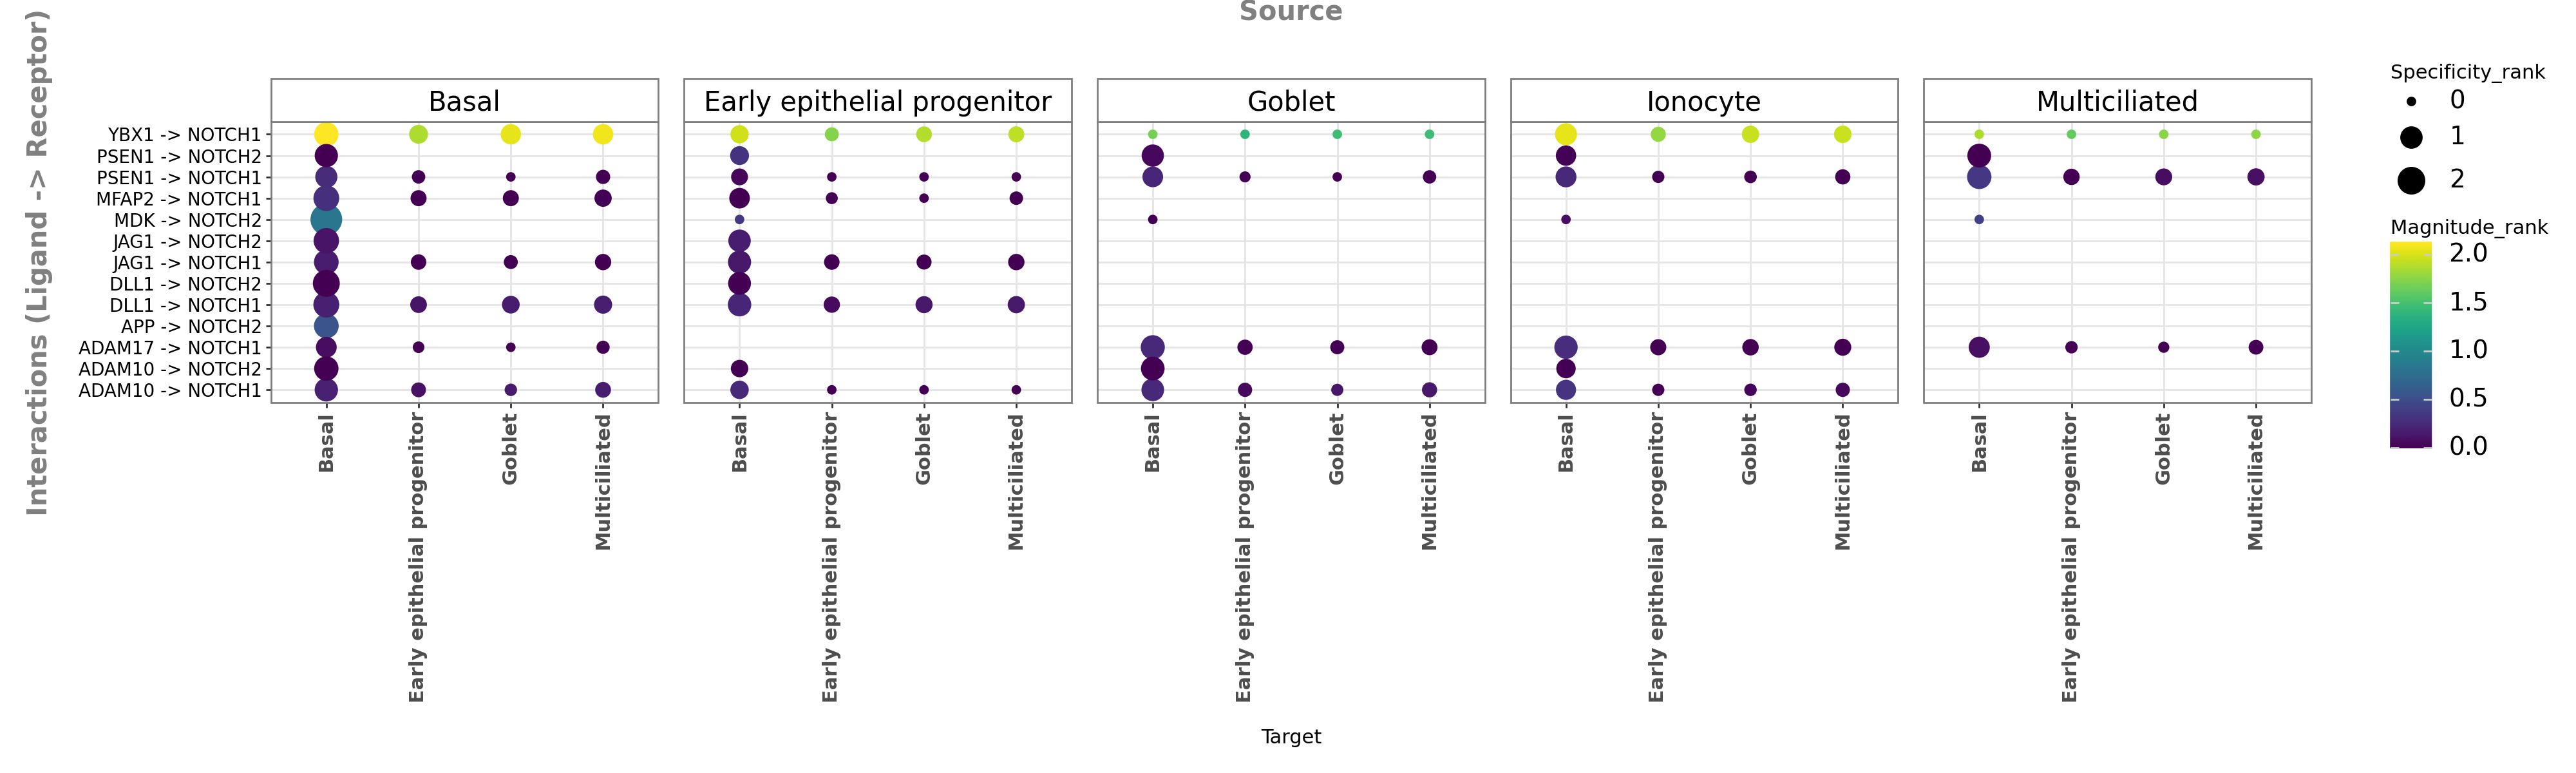

In [56]:
li.pl.dotplot(
    adata=adata_st22,
    uns_key="liana_res",
    receptor_complex=["NOTCH2","NOTCH1"],
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,
    inverse_size=True,
    figure_size=(20, 6)
)
